# EngSAF — Exploratory Data Analysis

EDA on the cleaned corpus produced by `app/engsaf/cleaning.py`, which runs on the raw corpus from `app/engsaf/loader.py`, profiled by `app/engsaf/profiling.py`.

Findings so far: 5,579 raw rows -> 2,454 cleaned rows, after fixing 53 encoding artifacts, dropping 1 blank answer, 15 duplicate `(question, student_answer)` rows, and 3,109 out-of-scope rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/cleaned/engsaf_cleaned.parquet')
df.shape

(2454, 6)

## Overview

In [2]:
df.dtypes

id                  str
question_id         str
question            str
student_answer      str
reference_answer    str
split               str
dtype: object

## Confirm the scope filter actually worked

Cleaning dropped rows whose question wasn't in the team-confirmed in-scope set - spot-check that exactly 18 questions remain and none of the out-of-scope topics (hydrology, materials science, etc.) slipped through.

In [3]:
df['question_id'].nunique()

18

## Answer length

Same baseline purpose as Mohler/SPRAG's - confirms this is genuinely short-answer data, and gives a length reference to compare AI-generated answers against later, so a detector can't just learn to key off length.

In [4]:
word_counts = df['student_answer'].str.split().str.len()
word_counts.describe()

count    2454.000000
mean       36.341483
std        29.336763
min         1.000000
25%        18.000000
50%        28.000000
75%        44.000000
max       286.000000
Name: student_answer, dtype: float64

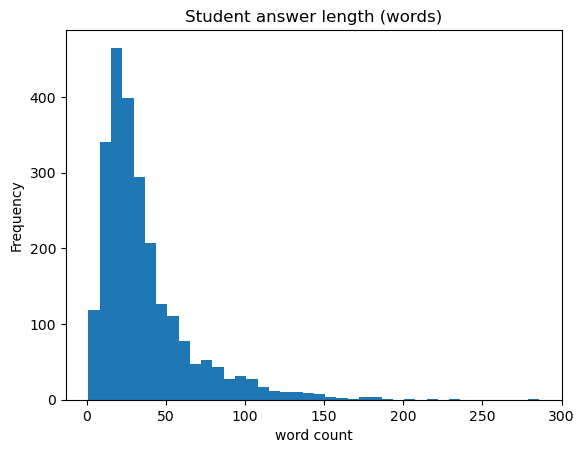

In [5]:
word_counts.plot(kind='hist', bins=40, title='Student answer length (words)')
plt.xlabel('word count')
plt.show()

## Rows per question (post-cleaning)

Sanity check on what's left after dropping out-of-scope rows - the OS/systems "State TRUE or FALSE" questions dominate since they were asked across many exam variants, while the lone software-engineering question ("Two advantages of separating declaration from definition") is the single largest contributor.

In [6]:
df['question'].value_counts()

question
Two      advantages of separating declaration from definition are: .....                                                                                                                                                                                                                                                                                                                                                                                  438
Q1. State TRUE or FALSE and justify. [6 marks] No correct justification, no marks. \n\nf. A spinlock is called a spinlock, as each attempt to acquire the lock will need spinning on the CPU (checking for lock status more than once), before the lock can be acquired.                                                                                                                                                                                  198
c. Assume the OS is using a lazy allocation policy for memory allocation to processes. On a page fa

## Split distribution (post-cleaning)

EngSAF ships with its own train/validation/test split (unlike SPRAG, which has none). This project's own `question-level-splits` (PP-115) will re-split from scratch once the combine step exists, so this is purely informational - not used downstream.

In [7]:
df['split'].value_counts()

split
train         2017
test           255
validation     182
Name: count, dtype: int64